In [3]:
import scipy
import sys
from skimage import io
import numpy as np
import numpy.matlib
import matplotlib
import skimage
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
import pandas as pd
from numpy import matlib
import seaborn as sns
import math
import os
import scipy.optimize
import scipy.io as sio
from scipy import stats
import scipy.ndimage
from scipy.interpolate import make_smoothing_spline
from pathlib import Path

sns.set(font_scale=1.5)
sns.set_style("whitegrid")

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Define the parameterized sigmoid (logistic) function
def sigmoid_func(x, L, x0, k, b):
    """
    L  : Maximum value (upper asymptote)
    x0 : Midpoint of the curve (inflection point)
    k  : Logistic growth rate (steepness)
    b  : Y-axis offset (lower asymptote)
    """
    return L / (1 + np.exp(k * (x - x0))) + b

WT_sorb_10kX_0008
WT_sorb_10kX_0008_cell_2.csv
Optimized Parameters:
L=-0.01, x0=2.63, k=-21.19, b=0.11
WT_sorb_10kX_0008_cell_1.csv
Optimized Parameters:
L=0.02, x0=61.99, k=2.03, b=0.17
WT_sorb_10kX_0006
WT_sorb_10kX_0006_cell_1.csv
Optimized Parameters:
L=-0.03, x0=94.15, k=0.13, b=0.65
WT_sorb_10kX_0006_cell_3.csv
Optimized Parameters:
L=0.02, x0=14.41, k=1.84, b=0.66
WT_sorb_10kX_0001
WT_sorb_10kX_0001_cell_2.csv
Optimized Parameters:
L=0.62, x0=39.27, k=0.04, b=0.22
WT_sorb_10kX_0007
WT_sorb_10kX_0007_cell_1.csv
Optimized Parameters:
L=0.52, x0=118.71, k=0.07, b=0.22
WT_sorb_10kX_0009
WT_sorb_10kX_0009_cell_2.csv


RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 1000.

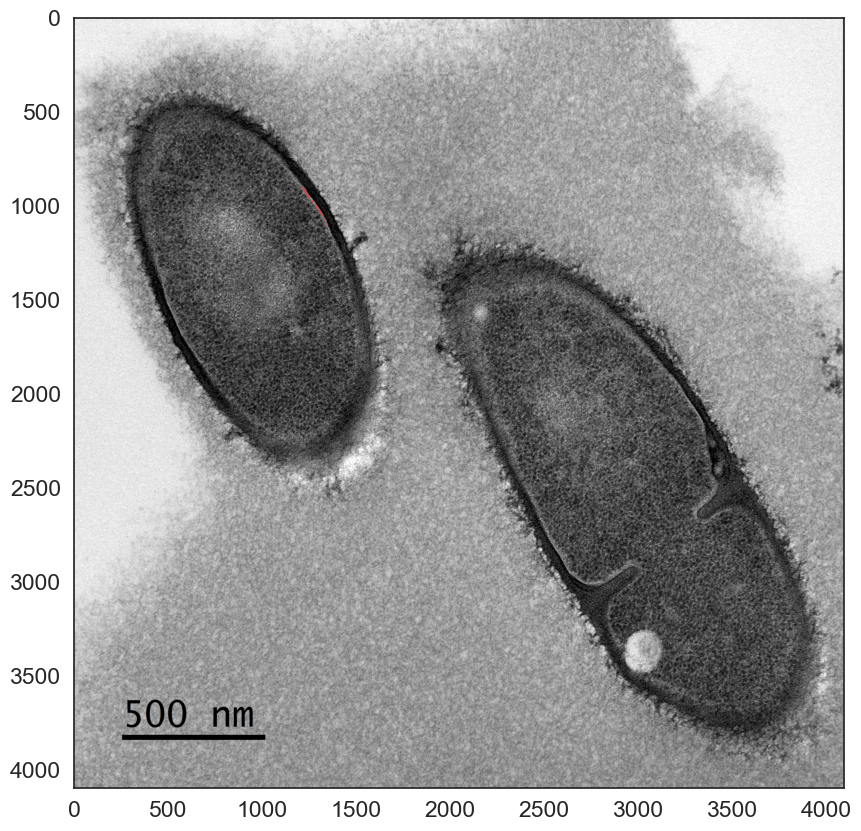

In [12]:
# Experiment specifics
base_path="/Volumes/data_ssd3/Barber_Lab/data"
expt_id="/20260602_TEM_HPF"
conds=["/WT_sorb_A3802", "/ponA_mg_A3805", "/ponA_sorb_A3809", "/tago_mg_A3812", "/tago_sorb_A3815", "/WT_mg_A3799"]
threshs=(255.0-np.array([39,33,30,25,61,32]))/255.0
bkgds=(255.0-np.array([203.4,176.125,170,170,147,190]))/255.0


# Parameters
scale=500.0/762.0 # nm/pixel.
depth=200
opp_depth=int(0/scale) # distance in nm to backtrack — allows you to precisely measure the position of the membrane
window=9
min_depth=100 # minimum depth for us to consider a cross-section for analysis
cutoff_length=int(opp_depth+min_depth/scale)
cutoff=0.2 # Peak prominence cutoff for "membrane" detection
offset_ind=int(30/scale)
# num_fits=40
rel_val=0.7
spacing=4.0 # spacing in pixels between adjacent fits

col=['Condition', 'Cell number', 'Thickness (nm)']
cell_thickness_df=pd.DataFrame(columns=col)

contours=[]

for cond_ind in range(len(conds)):
    # Navigate to a specific condition
    contours.append([])
    cond=conds[cond_ind]
    bkgd=bkgds[cond_ind]
    peak_val=threshs[cond_ind]
    dirs = [item.name for item in Path(base_path+expt_id+'/trace'+cond).iterdir() if item.is_dir() and item.name!='plots']
    # Work through all images from that condition
    cell_count=0
    for temp_dir in dirs:
        print(temp_dir)
        im1=io.imread(base_path+expt_id+cond+'/'+temp_dir+'.tif')
        im2=im1[:,:,0]
        # Plotting data
        sns.set_style('white')
        fig=plt.figure(figsize=[10,10])
        plt.imshow(im1)
        # Work through all traces from that image
        cell_traces_list= [item.name for item in Path(base_path+expt_id+'/trace'+cond+'/'+temp_dir).glob(temp_dir+'*.csv')]
        for name in cell_traces_list:
            print(name)
            coords=pd.read_csv(base_path+expt_id+'/trace'+cond+'/'+temp_dir+'/'+name)
            xv,yv=np.asarray(coords.X),np.asarray(coords.Y)
            lam=10
            if len(xv)<5: # We need to have additional points to make a spline of this sort
                xv1,yv1=np.copy(xv),np.copy(yv)
                while len(xv1)<5:
                    xv1,yv1=xv1[np.argsort(xv1)],yv1[np.argsort(xv1)]
                    temp_x,temp_y=np.mean(xv1[:2]),np.mean(yv1[:2])
                    xv1,yv1=np.append(xv1,temp_x),np.append(yv1,temp_y)
                # Fit a spline to the trace points
                spl = make_smoothing_spline(xv1[np.argsort(xv1)], yv1[np.argsort(xv1)], lam=lam)
            else:
                # Fit a spline to the trace points
                spl = make_smoothing_spline(xv[np.argsort(xv)], yv[np.argsort(xv)], lam=lam)
            xnew = np.arange(np.amin(xv), np.amax(xv), spacing)[1:-1]
            xnew1 = np.arange(np.amin(xv), np.amax(xv), spacing/10.0)
            ynew1=spl(xnew1)
            intensity_vals=np.nan*np.ones([len(xnew),int(depth/scale)+opp_depth])
            # Plotting spline values
            plt.plot(xnew1, spl(xnew1), '-.', label=fr'$\lambda=${lam}',color='r')
            # Calculate intensity along transverse slices
            slopes=[]
            for ind in np.arange(len(xnew)):
                point=np.nonzero(xnew1>xnew[ind])[0][0]
                slope=scipy.stats.linregress(xnew1[point-window:point+window],ynew1[point-window:point+window])
                slopes.append(slope)
                num_points=int(np.absolute(slope[0]*depth/scale)) # number of x values to change in order to get that amount of y change
                xs=np.sign(xv[-1]-xv[0])*np.sign(slope[0]) # determines whether x should increase or decrease.
                xrange=np.arange(xnew[ind],xnew[ind]-num_points,-1)
                yrange=float(spl(xnew1[point]))-1.0/slope[0]*(xrange-xnew1[point])
                # now let's unit-spaced coordinates along this line, from start to end.
                dx,dy=np.sign(xs)/np.sqrt(1+np.absolute(1.0/slope[0])),np.sign(-xv[-1]+xv[0])/np.sqrt(1+np.absolute(slope[0]))
                xcoords,ycoords=xnew[ind]+dx*np.arange(-opp_depth,int(depth/scale)),float(spl(xnew[ind]))+dy*np.arange(-opp_depth,int(depth/scale))
                sel_vals=np.nonzero((xcoords>=0)*(xcoords<=im1.shape[1])*(ycoords>=0)*(ycoords<=im1.shape[0]))
                if len(sel_vals[0])>cutoff_length:
                    intensity_vals[ind,sel_vals]=(255.0-im2[xcoords[sel_vals].astype(int),ycoords[sel_vals].astype(int)])/255.0
    
            # Let's just take the average over the first 30nm and find the first point where this intensity drops by 1/2 the difference 
            # between the peak 
            final_inds=[]
            xv_temp=scale*np.arange(intensity_vals.shape[1])
            x_data = xv_temp
            y_data = np.nanmean(intensity_vals,axis=0)
            sel_points=np.nonzero(~np.isnan(y_data))
            y_data=y_data[sel_points]
            x_data=x_data[sel_points]
            
            # 3. Provide an initial guess (p0) to help the optimizer converge
            initial_guess = [
                max(y_data) - min(y_data),  # L: approximate amplitude
                50,         # x0: approximate midpoint in nm
                0.1,                        # k: initial steepness scale
                min(y_data)                 # b: approximate floor
            ]
            
            # 4. Fit the curve using curve_fit
            # popt contains the optimized [L, x0, k, b] parameters
            popt, pcov = curve_fit(sigmoid_func, x_data, y_data, p0=initial_guess)
            
            print(f"Optimized Parameters:\nL={popt[0]:.2f}, x0={popt[1]:.2f}, k={popt[2]:.2f}, b={popt[3]:.2f}")
            
            # # 5. Generate smooth points for plotting the fitted line
            # x_fit = np.linspace(np.amin(x_data), np.amax(x_data), 200)
            # y_fit = sigmoid_func(x_fit, *popt)
            
            # # 6. Plot data and fit
            # plt.figure(figsize=(8, 5))
            # plt.scatter(x_data, y_data, color='gray', alpha=0.6, label='Noisy Data')
            # plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Fitted Sigmoid Curve')
            # plt.title('Sigmoid Curve Fitting in Python')
            # plt.xlabel('X')
            # plt.ylabel('Y')
            # plt.legend()
            # plt.grid(True)
            # plt.show()
            
            final_inds=np.nonzero(xv_temp>popt[1])[0][0]

            contours[-1].append([np.nanmean(intensity_vals,axis=0)]) # after the fact we will go back and take the relevant averages
                    
            for ind in np.arange(len(xnew)):
                xs=np.sign(xv[-1]-xv[0])*np.sign(slopes[ind][0]) # determines whether x should increase or decrease.
                yrange=float(spl(xnew1[point]))-1.0/slopes[ind][0]*(xrange-xnew1[point])
                # now let's unit-spaced coordinates along this line, from start to end.
                dx,dy=np.sign(xs)/np.sqrt(1+np.absolute(1.0/slopes[ind][0])),np.sign(-xv[-1]+xv[0])/np.sqrt(1+np.absolute(slopes[ind][0]))
                xcoords,ycoords=xnew[ind]+dx*np.arange(-opp_depth,int(depth/scale)),float(spl(xnew[ind]))+dy*np.arange(-opp_depth,int(depth/scale))
                temp_xcoords=[xcoords[opp_depth],xcoords[final_inds]]
                temp_ycoords=[ycoords[opp_depth],ycoords[final_inds]]
                plt.plot(temp_xcoords,temp_ycoords,'-',color='g',alpha=0.6)
                temp_df=pd.DataFrame(columns=col,data=[[cond[1:],cell_count,scale*(final_inds-opp_depth)]])
                cell_thickness_df=pd.concat([cell_thickness_df,temp_df])
            cell_count+=1
        if not(os.path.isdir(base_path+expt_id+'/trace'+cond+'/plots')):
            os.mkdir(base_path+expt_id+'/trace'+cond+'/plots')
        fig.savefig(base_path+expt_id+'/trace'+cond+'/plots/'+temp_dir+'.png',bbox_inches='tight',dpi=150)
        plt.close()

([0], [Text(0, 0, 'WT_sorb_A3802')])

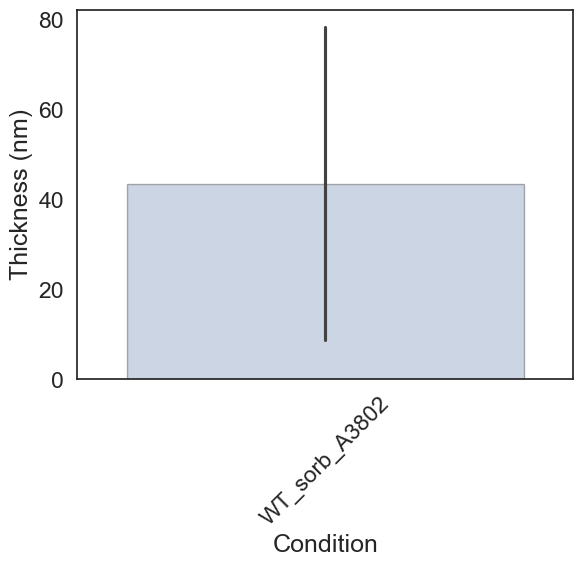

In [11]:
temp_df_out=cell_thickness_df.groupby(['Condition','Cell number'])['Thickness (nm)'].median().reset_index()
plot = sns.barplot(x='Condition', y='Thickness (nm)', data=temp_df_out, edgecolor='black', linewidth=1, native_scale=True, alpha=0.3, legend=False)
plt.xticks(rotation=45)

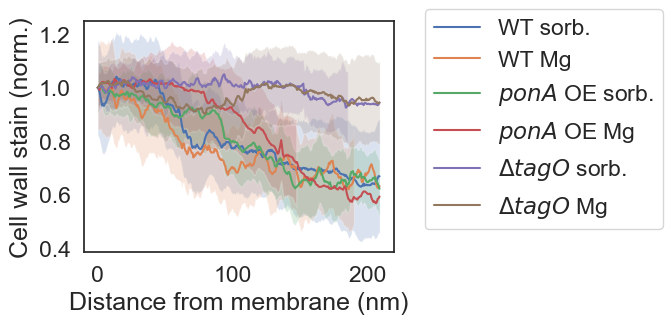

In [49]:
int_conts_ls=[]
fig=plt.figure(figsize=[4,3])
x=scale*np.arange(0,int(depth/scale)+opp_depth,1)
cutoff_num=2
cond_plotting=["/WT_sorb_A3802", "/WT_mg_A3799", "/ponA_sorb_A3809", "/ponA_mg_A3805", "/tago_sorb_A3815", "/tago_mg_A3812"]
cond_labels =["WT sorb.", "WT Mg", r"$ponA$ OE sorb.", r"$ponA$ OE Mg", r"$\Delta tagO$ sorb.", r"$\Delta tagO$ Mg"]
for cond in cond_plotting:
    ind=conds.index(cond)
    int_conts=np.nan*np.ones([len(contours[ind]),int(depth/scale)+opp_depth])
    for ind1 in range(len(contours[ind])):
        int_conts[ind1,:]=np.asarray(contours[ind][ind1])
    temp_v1=(np.sum(~np.isnan(int_conts),axis=0)<cutoff_num)
    for ind2 in range(int_conts.shape[1]):
        if temp_v1[ind2]:
            int_conts[:,ind2]=np.nan
    
        # if np.sum(~np.isnan(int_conts[:,ind2])<cutoff_num):
        #     int_conts[:,ind2]=np.nan*np.ones(int_conts.shape[0])
    int_conts_ls.append(int_conts)

    med=np.nanmedian(int_conts_ls[-1],axis=0)
    sel_vals=np.nonzero(~np.isnan(med))
    iqr=scipy.stats.iqr(int_conts_ls[-1],axis=0)
    med*=1.0/med[0]
    iqr*=1.0/med[0]
    med=med[sel_vals]
    iqr=iqr[sel_vals]
    plt.plot(x[sel_vals],med,label=cond_labels[cond_plotting.index(cond)])
    plt.fill_between(x[sel_vals],med+iqr/2.0,med-iqr/2.0,alpha=0.2)
plt.legend(loc=[1.1,0.1])
plt.xlabel('Distance from membrane (nm)')
plt.ylabel('Cell wall stain (norm.)')
fig.savefig(base_path+expt_id+'/wall_profile_norm.png',dpi=300,bbox_inches='tight')
plt.show()


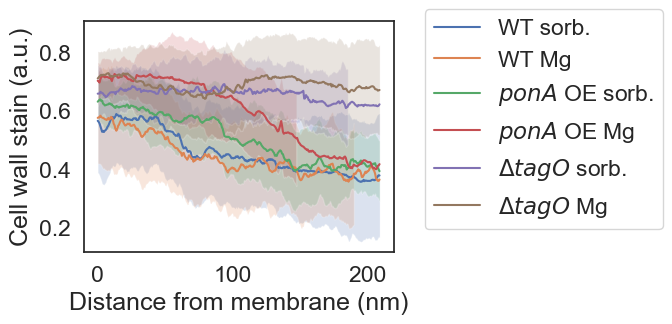

In [51]:
int_conts_ls=[]
fig=plt.figure(figsize=[4,3])
x=scale*np.arange(0,int(depth/scale)+opp_depth,1)
cutoff_num=2
cond_plotting=["/WT_sorb_A3802", "/WT_mg_A3799", "/ponA_sorb_A3809", "/ponA_mg_A3805", "/tago_sorb_A3815", "/tago_mg_A3812"]
cond_labels =["WT sorb.", "WT Mg", r"$ponA$ OE sorb.", r"$ponA$ OE Mg", r"$\Delta tagO$ sorb.", r"$\Delta tagO$ Mg"]
for cond in cond_plotting:
    ind=conds.index(cond)
    int_conts=np.nan*np.ones([len(contours[ind]),int(depth/scale)+opp_depth])
    for ind1 in range(len(contours[ind])):
        int_conts[ind1,:]=np.asarray(contours[ind][ind1])
    temp_v1=(np.sum(~np.isnan(int_conts),axis=0)<cutoff_num)
    for ind2 in range(int_conts.shape[1]):
        if temp_v1[ind2]:
            int_conts[:,ind2]=np.nan
    
        # if np.sum(~np.isnan(int_conts[:,ind2])<cutoff_num):
        #     int_conts[:,ind2]=np.nan*np.ones(int_conts.shape[0])
    int_conts_ls.append(int_conts)

    med=np.nanmedian(int_conts_ls[-1],axis=0)
    sel_vals=np.nonzero(~np.isnan(med))
    iqr=scipy.stats.iqr(int_conts_ls[-1],axis=0)
    # med*=1.0/med[0]
    # iqr*=1.0/med[0]
    med=med[sel_vals]
    iqr=iqr[sel_vals]
    plt.plot(x[sel_vals],med,label=cond_labels[cond_plotting.index(cond)])
    plt.fill_between(x[sel_vals],med+iqr/2.0,med-iqr/2.0,alpha=0.2)
plt.legend(loc=[1.1,0.1])
plt.xlabel('Distance from membrane (nm)')
plt.ylabel('Cell wall stain (a.u.)')
fig.savefig(base_path+expt_id+'/wall_profile.png',dpi=300,bbox_inches='tight')
plt.show()
